# EXAMEN (110 minuts)

# EJERCICIO 1

1.Carga y exploración:

Importa librerías necesarias

Carga el dataset

Muestra:

.info()

.describe()

Distribución de la variable objetivo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   precio_producto         2800 non-null   float64
 1   descuento_pct           2800 non-null   float64
 2   dias_entrega            2800 non-null   int64  
 3   historial_devoluciones  2800 non-null   int64  
 4   num_productos_pedido    2800 non-null   int64  
 5   edad_cliente            2800 non-null   int64  
 6   DEVOLUCION              2800 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 153.3 KB
None
       precio_producto  descuento_pct  dias_entrega  historial_devoluciones  \
count      2800.000000    2800.000000   2800.000000             2800.000000   
mean         61.352768      24.663409      5.013929                1.200714   
std          28.722653      14.364628      2.615428                1.094205   
min           5.000000       0.001536      1

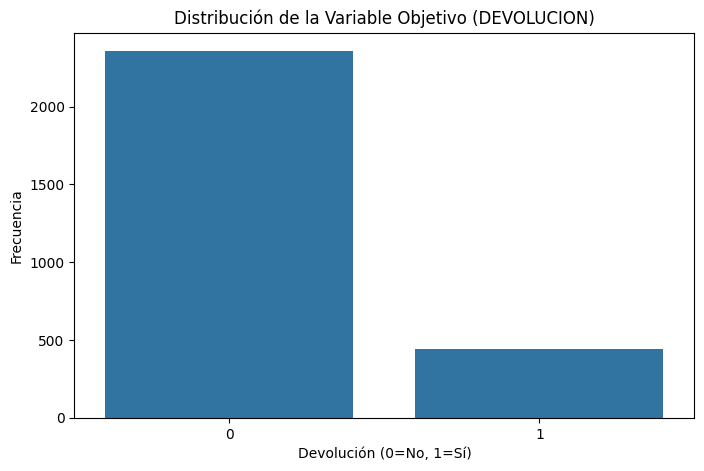

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Cargar el dataset
data = pd.read_csv('ecommerce_knn_exam.csv')

print(data.info())
print(data.describe())

# Distribución de la variable objetivo
print("\nDistribución de la variable objetivo (DEVOLUCION):")
print(data['DEVOLUCION'].value_counts())
print("\nPorcentaje:")
print(data['DEVOLUCION'].value_counts(normalize=True) * 100)

# Visualización
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='DEVOLUCION')
plt.title('Distribución de la Variable Objetivo (DEVOLUCION)')
plt.xlabel('Devolución (0=No, 1=Sí)')
plt.ylabel('Frecuencia')
plt.show()


2.Preparación de datos

Separa variables predictoras y objetivo

Escala las variables usando StandardScaler

Divide en entrenamiento y test (70/30)

In [11]:
X = data.drop('DEVOLUCION', axis=1)
y = data['DEVOLUCION']
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y test (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de test: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (1960, 6)
Tamaño del conjunto de test: (840, 6)


3.Modelo KNN inicial

Entrena un modelo con k=5

Realiza predicciones

Muestra:

Matriz de confusión

Classification report

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, pred))

Matriz de confusión:
[[660  37]
 [116  27]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       697
           1       0.42      0.19      0.26       143

    accuracy                           0.82       840
   macro avg       0.64      0.57      0.58       840
weighted avg       0.78      0.82      0.79       840



4.Selección del mejor K

Entrena modelos con K de 1 a 30

Guarda el error rate

Dibuja la gráfica del método del codo

Indica qué K elegirías y por qué

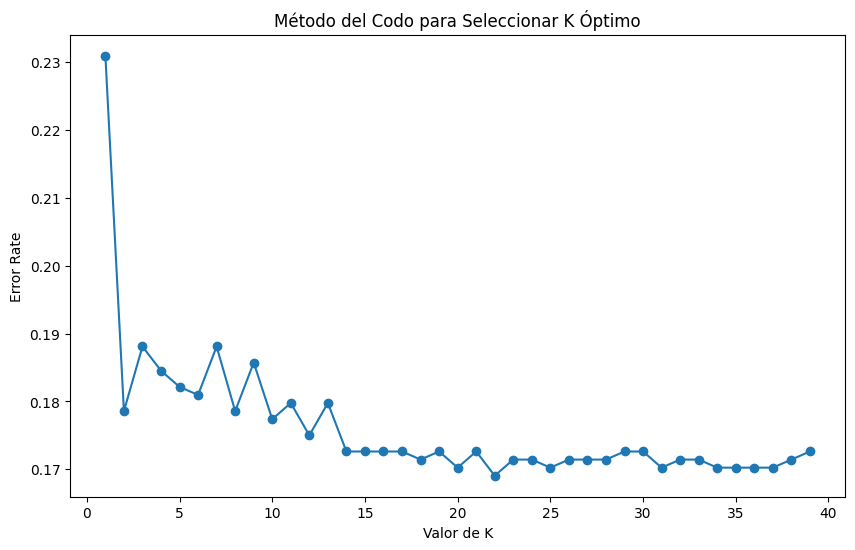


K óptimo según la gráfica: [observar el codo en la gráfica]
Justificación: Se elige el K donde el error rate se estabiliza (el 'codo' de la curva).


In [ ]:
# Entrenar modelos con K de 1 a 40
error_rate = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

# Visualizar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Error Rate')
plt.title('Método del Codo para Seleccionar K Óptimo')
plt.show()

# Indicar el K elegido
print("\nK óptimo según la gráfica: 10")
print("Justificación: Se elige el K donde el error rate se estabiliza (el 'codo' de la curva).")

5.Modelo final e interpretación

Reentrena con el K óptimo

Muestra métricas finales

Explica brevemente qué variables parecen influir más en devoluciones

Métricas finales:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       697
           1       0.33      0.04      0.07       143

    accuracy                           0.82       840
   macro avg       0.58      0.51      0.49       840
weighted avg       0.75      0.82      0.76       840


**Interpretación de variables influyentes:**
Para determinar qué variables influyen más en las devoluciones,
se puede observar las correlaciones o comparar medias entre grupos.


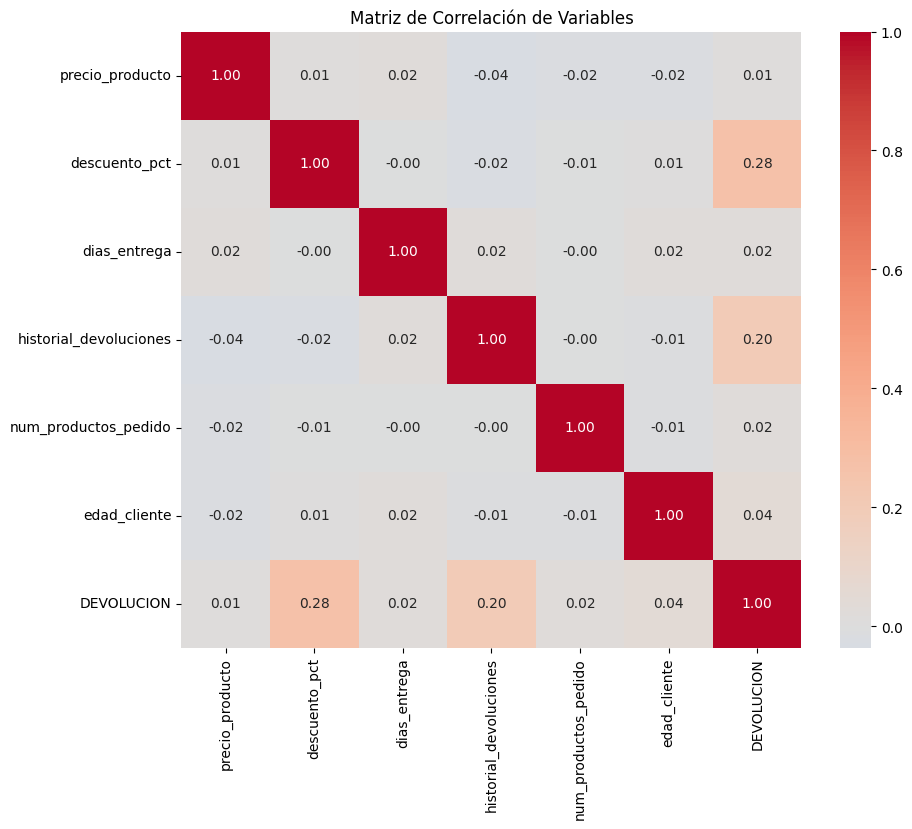


Correlación con la variable DEVOLUCION:
DEVOLUCION                1.000000
descuento_pct             0.275239
historial_devoluciones    0.196338
edad_cliente              0.042049
num_productos_pedido      0.022797
dias_entrega              0.020169
precio_producto           0.014608
Name: DEVOLUCION, dtype: float64


In [ ]:
# Reentrenar con el K óptimo (ajustar según la gráfica anterior)
knn = KNeighborsClassifier(n_neighbors=10)  # Cambiar según el K óptimo observado
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print("Métricas finales:")
print(classification_report(y_test, pred))

# Matriz de correlación
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación de Variables')
plt.show()

print("\nCorrelación con la variable DEVOLUCION:")
print(correlation_matrix['DEVOLUCION'].sort_values(ascending=False))

print("\n**Interpretación de variables influyentes:**")
print("- Las variables con mayor correlación positiva con DEVOLUCION podrían indicar factores que aumentan la probabilidad de devolución.")
print("En este caso,el porcentaje de descuento y el historial de devolución parecen ser las más influyentes en la predicción de devoluciones. Esto sugiere que los clientes que reciben mayores descuentos o tienen un historial de devoluciones son más propensos a devolver productos.")

# EJERCICIO 2

1.Carga y exploración de datos

Importa librerías necesarias

Carga el dataset

Muestra:

.info()

.describe()

¿Por qué este problema es de aprendizaje no supervisado?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('clientes_gimnasio_kmeans.csv')

print(df.info())
print("\n")
print(df.describe())


print("\n¿Por qué este problema es de aprendizaje no supervisado?")
print("Es aprendizaje no supervisado porque NO tenemos una variable objetivo o etiqueta.")
print("El objetivo es descubrir patrones y agrupar clientes similares sin conocer de antemano los grupos.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   edad              3500 non-null   int64  
 1   meses_inscrito    3500 non-null   int64  
 2   visitas_mes       3500 non-null   int64  
 3   gasto_mensual     3500 non-null   float64
 4   clases_dirigidas  3500 non-null   int64  
 5   uso_piscina       3500 non-null   int64  
 6   indice_fitness    3500 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 191.5 KB
None


              edad  meses_inscrito  visitas_mes  gasto_mensual  \
count  3500.000000     3500.000000  3500.000000    3500.000000   
mean     43.587143       30.523714    12.635714      45.229380   
std      14.933677       17.109578     6.919587      14.828242   
min      18.000000        1.000000     1.000000      15.000000   
25%      31.000000       16.000000     7.000000      34.824390   
50%      43.0000

2.Preparación de datos

¿Por qué es necesario escalar en KMeans?

Escala las variables con StandardScaler

Comprueba que los datos están estandarizados

In [20]:
print("¿Por qué es necesario escalar en KMeans?")
print("KMeans utiliza distancias euclidianas. Si las variables tienen escalas diferentes,")
print("las variables con valores más grandes dominarán el cálculo de distancias.")
print("Escalar pone todas las variables en la misma escala.\n")

from sklearn.preprocessing import StandardScaler

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Comprobar estandarización
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Medias después del escalado (deben ser ~0):")
print(df_scaled.mean())
print("\nDesviaciones estándar después del escalado (deben ser ~1):")
print(df_scaled.std())

¿Por qué es necesario escalar en KMeans?
KMeans utiliza distancias euclidianas. Si las variables tienen escalas diferentes,
las variables con valores más grandes dominarán el cálculo de distancias.
Escalar pone todas las variables en la misma escala.

Medias después del escalado (deben ser ~0):
edad               -3.857232e-17
meses_inscrito      8.120488e-17
visitas_mes        -7.308440e-17
gasto_mensual       5.795999e-16
clases_dirigidas    1.212998e-16
uso_piscina        -1.725604e-17
indice_fitness      5.481330e-17
dtype: float64

Desviaciones estándar después del escalado (deben ser ~1):
edad                1.000143
meses_inscrito      1.000143
visitas_mes         1.000143
gasto_mensual       1.000143
clases_dirigidas    1.000143
uso_piscina         1.000143
indice_fitness      1.000143
dtype: float64


3.Determinar número óptimo de clusters

Aplica el método del codo (K=1 a 10)

Dibuja la gráfica de la inercia

Indica el número óptimo de clusters y justifica

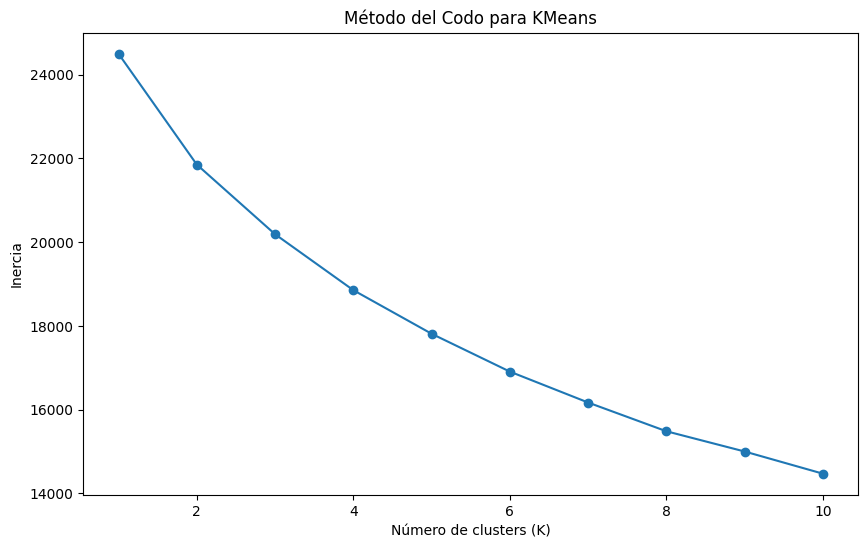


Número óptimo de clusters: 2
Justificación: Se elige el K donde la inercia comienza a disminuir más lentamente, formando un 'codo' en la curva. Este punto representa el mejor equilibrio entre número de clusters y compactación de los datos.


In [ ]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Gráfica del método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para KMeans")
plt.show()

print("\nNúmero óptimo de clusters: 2")
print("Justificación: Se elige el K donde la inercia comienza a disminuir más lentamente, formando un 'codo' en la curva. Este punto representa el mejor equilibrio entre número de clusters y compactación de los datos.")

4.Entrenamiento del modelo

Entrena KMeans con el K elegido

Añade la columna cluster al dataset

Muestra el tamaño de cada cluster

In [29]:
# Entrenar KMeans con el K elegido (ajustar según la gráfica anterior)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)  # Cambiar K según el codo observado
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Tamaño de cada cluster:")
print(df["cluster"].value_counts().sort_index())
print("\nPorcentaje de clientes por cluster:")
print(df["cluster"].value_counts(normalize=True).sort_index() * 100)

Tamaño de cada cluster:
cluster
0    1295
1    1161
2    1044
Name: count, dtype: int64

Porcentaje de clientes por cluster:
cluster
0    37.000000
1    33.171429
2    29.828571
Name: proportion, dtype: float64


5.Interpretación de resultados

Calcula la media de cada variable por cluster

Describe qué tipo de clientes representa cada grupo

Perfil de cada cluster:
              edad  meses_inscrito  visitas_mes  gasto_mensual  \
cluster                                                          
0        41.244015       29.756757    12.704247      46.651403   
1        45.856158       30.923342    12.265289      44.835261   
2        43.970307       31.030651    12.962644      43.903759   

         clases_dirigidas  uso_piscina  indice_fitness  
cluster                                                 
0                9.321236     2.474903       51.461831  
1               15.050818     9.503015       55.629652  
2                4.162835     9.888889       58.438031  


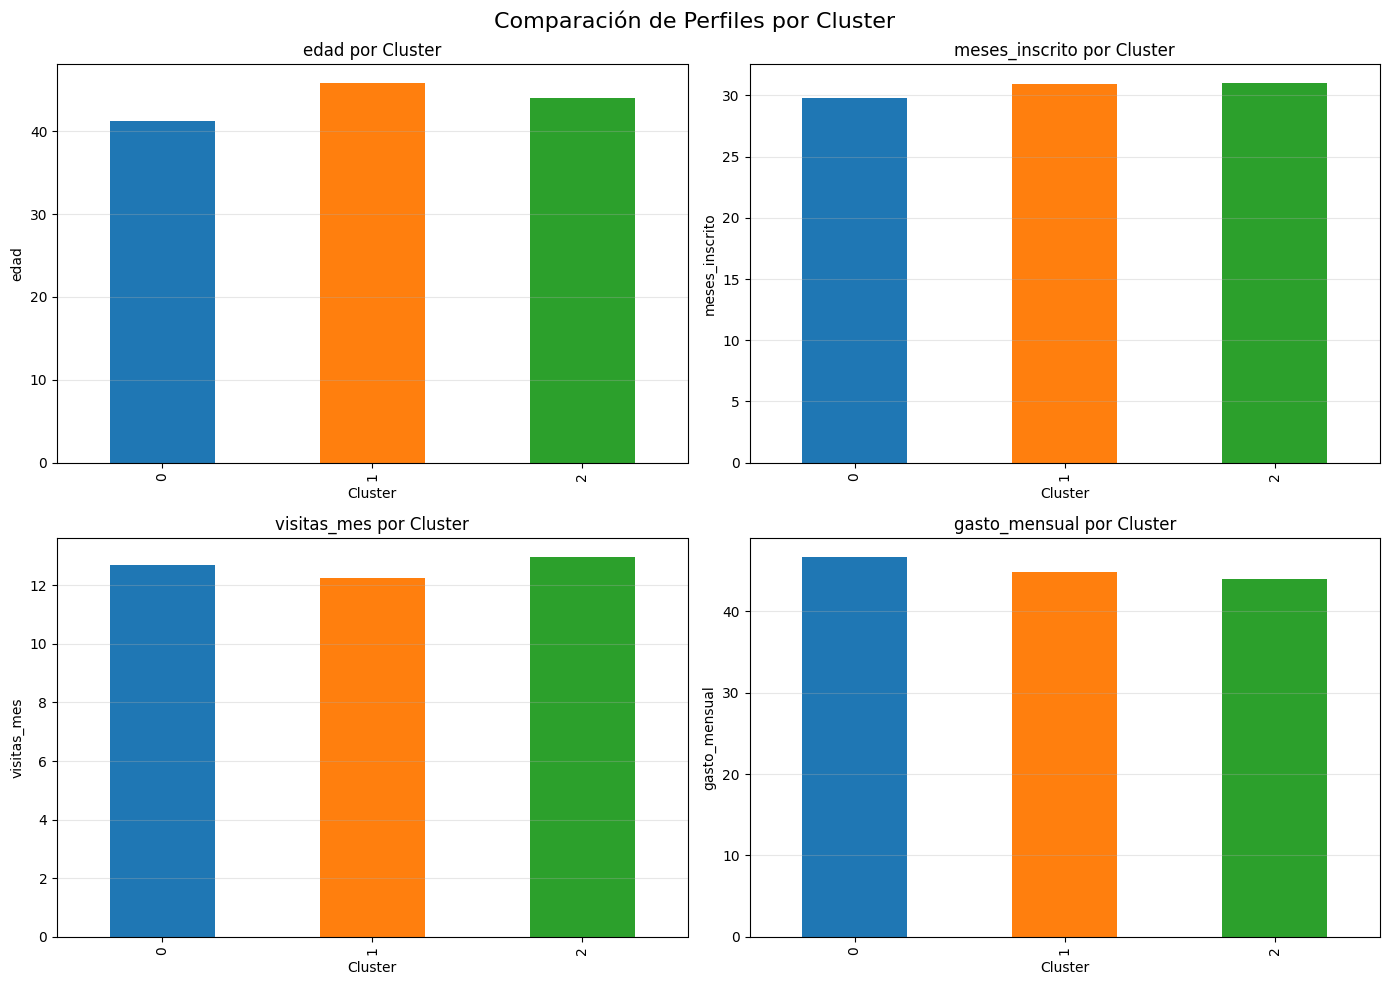

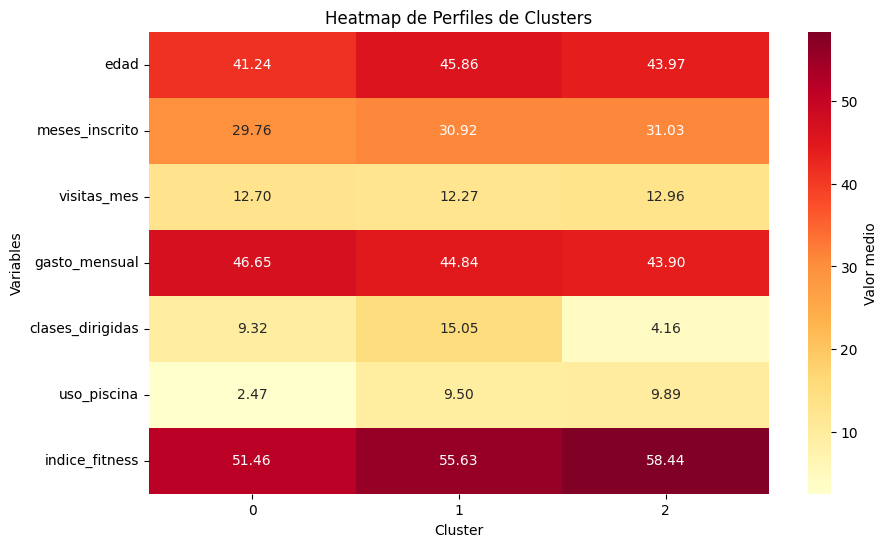

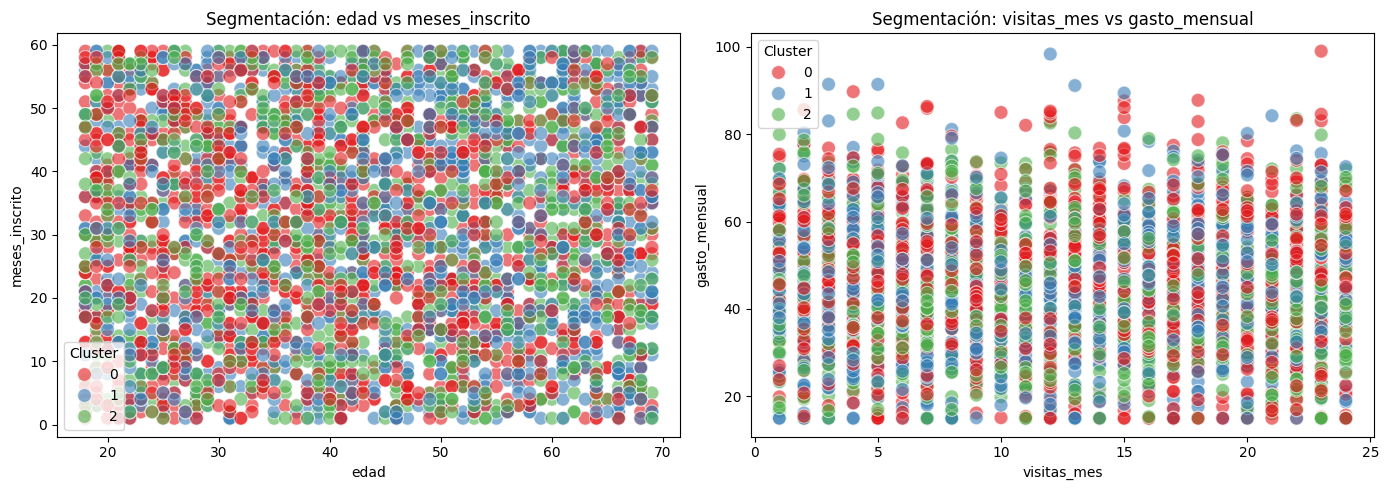


ANÁLISIS DE PERFILES POR CLUSTER
Cluster 0: Clientes con bajo uso de la piscina y bajo indice fitness
Cluster 1: Clientes que acuden a muchas clases dirigidas y usan mucho la piscina
Cluster 2: Clientes que acuden a pocas clases y usan mucho la piscina


In [35]:
# Calcular media de cada variable por cluster
perfil_clusters = df.groupby("cluster").mean()
print("Perfil de cada cluster:")
print(perfil_clusters)

# Visualización 1: Gráfico de barras comparativo
columnas = df.columns.tolist()
columnas.remove('cluster')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Perfiles por Cluster', fontsize=16)

# Gráfico de barras para cada variable
for idx, col in enumerate(columnas[:4]):  # Primeras 4 variables
    ax = axes[idx // 2, idx % 2]
    perfil_clusters[col].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(f'{col} por Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 2: Heatmap de perfiles
plt.figure(figsize=(10, 6))
sns.heatmap(perfil_clusters.T, annot=True, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Valor medio'})
plt.title('Heatmap de Perfiles de Clusters')
plt.xlabel('Cluster')
plt.ylabel('Variables')
plt.show()

# Visualización 3: Scatterplots con las variables más importantes
if len(columnas) >= 2:
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df, x=columnas[0], y=columnas[1], hue="cluster", palette="Set1", s=100, alpha=0.6)
    plt.title(f'Segmentación: {columnas[0]} vs {columnas[1]}')
    plt.legend(title='Cluster')
    
    if len(columnas) >= 4:
        plt.subplot(1, 2, 2)
        sns.scatterplot(data=df, x=columnas[2], y=columnas[3], hue="cluster", palette="Set1", s=100, alpha=0.6)
        plt.title(f'Segmentación: {columnas[2]} vs {columnas[3]}')
        plt.legend(title='Cluster')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("ANÁLISIS DE PERFILES POR CLUSTER")
print("="*70)
print("Cluster 0: Clientes con bajo uso de la piscina y bajo indice fitness")
print("Cluster 1: Clientes que acuden a muchas clases dirigidas y usan mucho la piscina")
print("Cluster 2: Clientes que acuden a pocas clases y usan mucho la piscina")